In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection, Line3DCollection
from cvxopt import matrix, printing
from scipy.spatial.transform import Rotation as R
from mpl_toolkits.axes_grid1 import ImageGrid
import pytransform3d.camera as pc
import pytransform3d.transformations as pt
import fnmatch
import os

In [2]:
#%matplotlib qt
%matplotlib inline

# Camera calibration

Use OpenCV to calibrate the camera so that we can undistort images.

https://docs.opencv.org/4.x/dc/dbb/tutorial_py_calibration.html


#### Utility function (display images in a grid)

The following function displays a set of images as a M x N rectangular grid.

In [3]:
def display_images_in_grid(images, nrows, ncols, sx, sy):
    # Display all images in a nrows x ncols tight grid

    fig = plt.figure(figsize=(sx, sy))
    grid = ImageGrid(fig, 111,  # similar to subplot(111)
                     nrows_ncols=(nrows, ncols),  # creates 2x2 grid of axes
                     axes_pad=0.1  # pad between axes in inch.
                     )

    for ax, im in zip(grid, images):
        # Iterating over the grid returns the Axes.
        ax.imshow(im)
        ax.set_axis_off()

    plt.show()
    
    return

#### Function to estimate the calibration matrix
The following function calculates the calibration given a set of images of a checkerboard pattern seen from different view points.


In [4]:
def obtain_camera_matrix_distcoefs():

    # Criteria for termination of the iterative process of corner refinement
    terminate_criteria = (cv.TERM_CRITERIA_EPS +
                          cv.TERM_CRITERIA_MAX_ITER, 30, 0.001)

    # Number of corners to look for in the chessboard
    horizontal_corners = 9
    vertical_corners = 6

    # Create an array of object points. These are the 3D coordinates of the corners in the real world
    object_points = np.zeros(
        (horizontal_corners * vertical_corners, 3), np.float32)
    object_points[:, :2] = np.mgrid[0:horizontal_corners,
                                    0:vertical_corners].T.reshape(-1, 2)
    
    # Count the number of calibration images to be used
    num_images = len(fnmatch.filter(os.listdir("calibration/"), '*.jpg'))
    print('File Count:', num_images)    

    # Load the image, scale it, and make it grayscale
    cal_imgs = []
    gray_imgs = []
    for i in range(0, num_images):
        image = cv.imread("calibration/cal{}.jpg".format(i))
        scaled = cv.resize(image, (0, 0), fx=0.2, fy=0.2)
        color_fixed = cv.cvtColor(scaled, cv.COLOR_BGR2RGB)
        gray = cv.cvtColor(scaled, cv.COLOR_BGR2GRAY)
        cal_imgs.append(color_fixed)
        gray_imgs.append(gray)

    # Find the corners in the chessboards
    ret = []
    corners = []
    for i in range(0, num_images):
        ret_temp, corners_temp = cv.findChessboardCorners(
            gray_imgs[i], (horizontal_corners, vertical_corners), None)

        if ret_temp != True:
            raise Exception("Chessboard not found in image {}".format(i))

        ret.append(ret_temp)
        corners.append(corners_temp)

    ###------------------------------------------------------------------###
    #  Refine corners and display results                                  #
    ###------------------------------------------------------------------###        
        
    # Refine the corners
    corners_refined = []
    for i in range(0, num_images):
        corners_refined_temp = cv.cornerSubPix(
            gray_imgs[i], corners[i], (11, 11), (-1, -1), terminate_criteria)
        corners_refined.append(corners_refined_temp)
   
    # Calibration images showing refined corners 
    refined_corner_images = [cv.drawChessboardCorners(cal_imgs[i], 
                                                      (horizontal_corners, vertical_corners), 
                                                      corners_refined[i], ret[i])
                      for i in range(0,num_images)]     
    
    ###------------------------------------------------------------------###
    #  Calibrate camera                                                    #
    ###------------------------------------------------------------------###        
    
    # Calculate camera calibration parameters
    reprojection_error, camera_matrix, distortion_coefficients, _, _ = cv.calibrateCamera(
        [object_points, object_points, object_points], corners_refined, gray.shape[::-1], None, None)

    # Refine the camera matrix
    alpha = 0
    refined_camera_matrix, roi = cv.getOptimalNewCameraMatrix(
        camera_matrix, distortion_coefficients, gray.shape[::-1], alpha, gray.shape[::-1])


    # Undistort the images
    undistorted_images = []
    for i in range(0, num_images):
        undistorted_image = cv.undistort(cal_imgs[i], 
                                         camera_matrix, 
                                         distortion_coefficients, None, refined_camera_matrix)
        undistorted_images.append(undistorted_image)
        
    ###------------------------------------------------------------------###
    #  Calculate and show undistorted images                                        #
    ###------------------------------------------------------------------###        
        
    # Crop the images
    undistorted_images_cropped = []
    for i in range(0, num_images):
        x, y, w, h = roi
        undistorted_image_cropped = undistorted_images[i][y:y+h, x:x+w]
        undistorted_images_cropped.append(undistorted_image_cropped)

    # Display images as a grid
    display_images_in_grid(undistorted_images_cropped, 1, num_images, 20, 20)    
   
    
    return camera_matrix, refined_camera_matrix, distortion_coefficients

File Count: 3


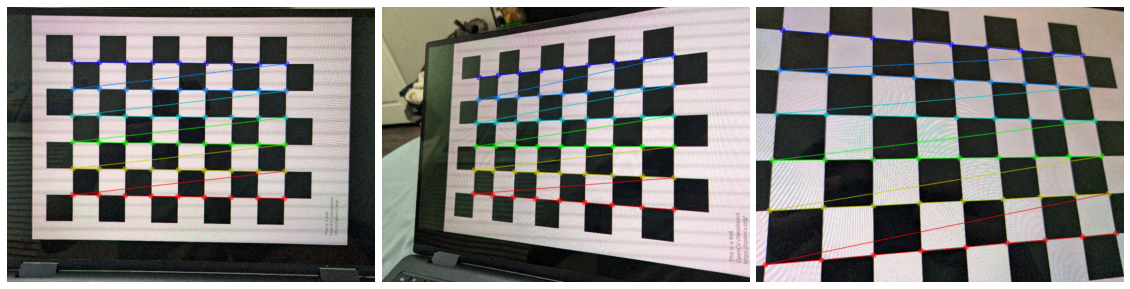

---------------------------------------------------
Matrix of intrinsic parameters
---------------------------------------------------
Lambda = 
[655.94   0.00 403.36]
[  0.00 657.72 293.74]
[  0.00   0.00   1.00]



In [5]:
# Estimate the camera matrix and lens distortion
camera_matrix, refined_camera_matrix, distortion_coefficients = obtain_camera_matrix_distcoefs()

# Matrix of intrinsic parameters
print('---------------------------------------------------')
print('Matrix of intrinsic parameters')
print('---------------------------------------------------')
print('Lambda = ')
printing.options['dformat'] = '%.2f'
printing.options['width'] = -1
print(matrix(refined_camera_matrix))

### Feature detection and matching

Here, we will use a set of four feature pairs corresponding to the corner of rectangles on the images. 

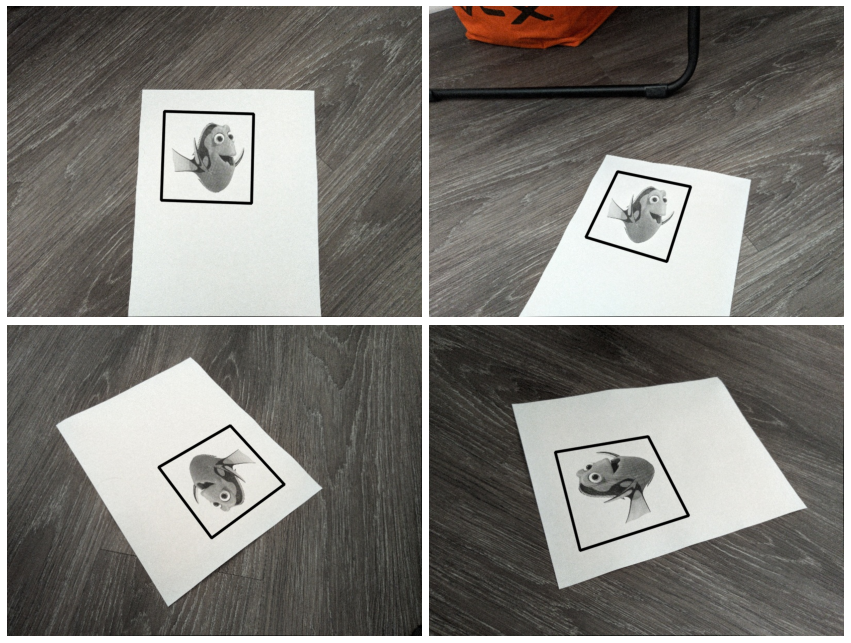

In [6]:
# Make a list of input images of the rectangles. 
raw_images = [cv.imread('dory_rectangle{}.jpg'.format(i)) for i in range(0, 4)]
# Convert all images in the list from BGR to RGB to show correct colors. 
raw_images = [cv.cvtColor(img, cv.COLOR_BGR2RGB) for img in raw_images]

########################################################################
# In this example, the aw images are already scaled down and corrected 
# for lens distortion. When using images from your own camera, you 
# might need to scale them down and also correct for lens distortion. 
# To do that, uncomment the following steps and adapt the names of variables. 
########################################################################

# Scale the raw images down
#scaled_images = [cv.resize(img, (0, 0), fx=0.2, fy=0.2) for img in raw_images]

# Undistort the images using the refined camera matrix (removes lens distortion)
#undistorted_images = [cv.undistort(img, camera_matrix, distortion_coefficients, None, refined_camera_matrix) for img in scaled_images]

# Display images as a grid
display_images_in_grid(raw_images, 2, 2, 15, 15)

# Estimate homography transformation

Estimate the matrix $\Phi$ of the planar projective transformation.


### Input data: reference points and image (feature) points
The input data for the homography calculation are a set of pairs of coordinates. Each pair is formed by a set of landmarks on the reference pattern and a set of correspoding feature points on the image of the reference pattern. 

In [7]:
ref_points = [[[  0,   0]],
              [[  0, 511]],
              [[511, 511]],
              [[511,   0]]]

img_points =[
        [ # image 0
        [[305, 206]],
        [[298, 374]],
        [[471, 382]],       
        [[476, 207]]
        ], 
        [ # image 1
        [[363, 320]],
        [[302, 446]],
        [[458, 493]],
        [[504, 349]]
        ],
        [ # image 2
        [[534, 308]],
        [[431, 195]],
        [[292, 275]],
        [[394, 411]]
        ],
        [ # image 3
        [[291, 434]],
        [[500, 369]],
        [[423, 216]],
        [[243, 246]]
        ]
    ]

## Show the labeled corners on the images

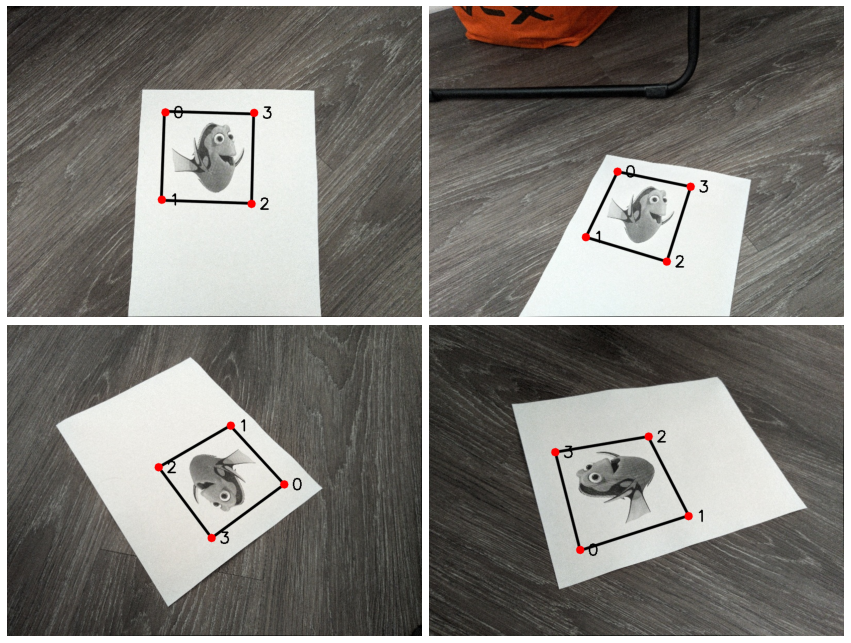

In [8]:
labelled_points = raw_images

for i in range(0,4):
    for j in range(0,4):
        # Draw circles at the image features
        labelled_points[i] = cv.circle(labelled_points[i],
                           (np.int32(img_points[i][j][0][0]),np.int32(img_points[i][j][0][1])), 
                           8, (255,0,0), -1)
        
        # Draw text labels at the image features 
        labelled_points[i] = cv.putText(labelled_points[i],'{}'.format(j), 
                          (np.int32(img_points[i][j][0][0]+15),np.int32(img_points[i][j][0][1]+10)), 
                          cv.FONT_HERSHEY_SIMPLEX, 1, (0,0,0), 2)

display_images_in_grid(labelled_points, 2, 2, 15, 15)

In [9]:
# Find the homography matrix for each image
#
# I'm using the built-in function instead of computing it myself because the built-in function
# filters out the outliers, which I wasn't able to get working well enough on my own
homography_matrices = []
matches_mask = []

printing.options['dformat'] = '%.3f'
printing.options['width'] = -1

for pts, idx in zip(img_points, range(0,4)):
    h, mask = cv.findHomography(np.array(ref_points), np.array(pts), cv.RANSAC, 5.0)
    
    print(f"H({idx}) = ")
    print(matrix(h))
    homography_matrices.append(h)
    matches_mask.append(mask.ravel().tolist())

H(0) = 
[  0.298  -0.021 305.000]
[ -0.014   0.319 206.000]
[ -0.000  -0.000   1.000]

H(1) = 
[  0.192  -0.191 363.000]
[ -0.002   0.141 320.000]
[ -0.000  -0.000   1.000]

H(2) = 
[ -0.363  -0.124 534.000]
[  0.109  -0.186 308.000]
[ -0.000   0.000   1.000]

H(3) = 
[  0.020   0.587 291.000]
[ -0.253   0.004 434.000]
[  0.000   0.000   1.000]



# Extract extrinsic parameters

Factorize the homography matrix to extract the camera rotation and translation.


In [10]:
def extractExtrinsicParametersFromHomography(Phi, Lambda_inverse):
    """
    extractExtrinsicParametersFromHomography factorizes the homograpgy transformation to extract the camera pose, 
                                             i.e., rotation matrix and translation vector.

    Input arguments:
    ------------------
        Phi:    3x3 homography matrix 
        Lambda: 3x3 intrinsics matrix 
    
    return: 
    -------
        Omega: 3x3 Rotation matrix, 
        tau:   3x1 translation vector 
        
    """ 
    
    homography = Phi
    inverse_intrinsic_camera_matrix = Lambda_inverse
    
    # # Use openCV to estimate the camera's position and orientation
    # _, rotation, translation, _ = cv.decomposeHomographyMat(
    #     homography, camera_matrix)

    # # Add the rotation matrix and translation vector to the list of camera poses
    # camera_rotations.append(rotation)
    # camera_translations.append(translation)

    # Multiply the homography matrix by the inverse intrinsic camera matrix to eliminiate the effect
    # of the camera's intrinsic parameters
    homography_extrinsic = np.dot(inverse_intrinsic_camera_matrix, homography)

    # Estimate the first two columns of the rotation matrix by computing the SVD of the first two
    # columns of the homography matrix
    U, L, Vt = np.linalg.svd(homography_extrinsic[:, 0:2])
    new_L = np.array([[1, 0], [0, 1], [0, 0]])
    rotation_matrix = U @ new_L @ Vt

    # Estimate the third column of the rotation matrix by taking the cross product of the first two
    # columns
    third_column = np.cross(rotation_matrix[:, 0], rotation_matrix[:, 1])

    
    rotation_matrix = np.c_[rotation_matrix, third_column]

    # Verify that the rotation matrix is positive by checking its determinant
    if np.linalg.det(rotation_matrix) < 0:
        rotation_matrix[:, 2] *= -1

    # Estimate the scaling factor by taking the average of the scaling factors between the original
    # extrinsic homography matrix and the first two columns of the rotation matrix
    scaling_factor = np.sum(homography_extrinsic[:, 0:2] / rotation_matrix[:, 0:2]) / 6

    # Estimate the translation vector by dividing the third column of the extrinsic homography
    # matrix by the scaling factor
    translation = homography_extrinsic[:, 2] / scaling_factor
    
    # Rotation and translatioin
    Omega = rotation_matrix
    tau = translation
    
    return Omega, tau


In [11]:
# Calculate the inverse of the intrinsic camera matrix
inverse_intrinsic_camera_matrix = np.linalg.inv(camera_matrix)

camera_rotations = []
camera_translations = []
for homography in homography_matrices:
    # Extract extrinsic parameters from homography
    rotation_matrix, translation = extractExtrinsicParametersFromHomography(homography, inverse_intrinsic_camera_matrix)
    
    # Add the rotation matrix and translation vector to the list of camera poses
    camera_rotations.append(rotation_matrix)
    camera_translations.append(translation)
    
# Reference frame    
camera_rotations.append(np.eye(3))
camera_translations.append(np.array([0, 0, 0]))


# Print the camera poses
for i, (rotation, translation) in enumerate(zip(camera_rotations, camera_translations)):
    print("--------------------------------------")
    print("Camera pose {}:".format(i))
    print("--------------------------------------\n")
    print("Rotation:")
    print(matrix(rotation))
    print("Translation:")
    print(matrix(translation))


--------------------------------------
Camera pose 0:
--------------------------------------

Rotation:
[ 0.988 -0.034  0.152]
[ 0.026  0.998  0.055]
[-0.153 -0.050  0.987]

Translation:
[-297.115]
[-266.913]
[1999.915]

--------------------------------------
Camera pose 1:
--------------------------------------

Rotation:
[ 0.913 -0.357  0.198]
[ 0.154  0.751  0.641]
[-0.378 -0.555  0.741]

Translation:
[-140.616]
[  90.648]
[2311.788]

--------------------------------------
Camera pose 2:
--------------------------------------

Rotation:
[-0.779 -0.614 -0.126]
[ 0.475 -0.709  0.522]
[-0.410  0.347  0.844]

Translation:
[ 376.917]
[  40.073]
[1905.050]

--------------------------------------
Camera pose 3:
--------------------------------------

Rotation:
[-0.383  0.895 -0.228]
[-0.735 -0.145  0.663]
[ 0.560  0.421  0.713]

Translation:
[-205.813]
[ 256.912]
[1212.507]

--------------------------------------
Camera pose 4:
--------------------------------------

Rotation:
[1.000 0.000

### Draw the cameras (change coordinate frames)
To draw the cameras, we need to keep in mind that the camera-pose matrices that have been estimated from the homography transformations are written in terms of camera coordinate frames. As a result, we cannot use those matrices directly to plot the cameras. If we do, the cameras will not display properly. Instead, we need to calculate the inverse of the camera-pose matrices to obtain the camera pose written with respect to global coordinates. 

The camera pose is represented by a rigid-body transformation, i.e.: 

$$
\begin{align}
    T = 
    \begin{bmatrix}
        R & t \\
        {\bf 0} & 1
    \end{bmatrix},
\end{align}
$$

which has the following inverse: 

$$
\begin{align}
    T^{-1} = 
    \begin{bmatrix}
        R^\mathsf{T} & -R^\mathsf{T}t \\
        {\bf 0} & 1
    \end{bmatrix}.
\end{align}
$$

In [12]:
# default parameters of a camera in Blender
sensor_size = np.array([0.036, 0.024])
intrinsic_matrix = np.array([
    [0.05, 0, sensor_size[0] / 2.0],
    [0, 0.05, sensor_size[1] / 2.0],
    [0, 0, 1]
])
virtual_image_distance = 3

In [13]:
%matplotlib qt

# Draw each camera's position and orientation in the 3D plot as a sphere with a pyramid pointing
# in the direction of the camera's orientation
for rotation, translation, cam_idx in zip(camera_rotations, camera_translations, range(0,5)):

    translation = 3*translation / raw_images[0].shape[0]

    R = rotation
    t = np.array([translation]).T


    cam2world = np.block([R,t])
    cam2world = np.block([[cam2world],[0,0,0,1]])
    cam2world = np.linalg.inv(cam2world)
    
    print("--------------------------------------")
    print("Frame[{}] = ".format(cam_idx))
    print(matrix(cam2world))

    ax = pt.plot_transform(A2B=cam2world, s=2)
    pc.plot_camera(ax, 
                   cam2world=cam2world, 
                   M=intrinsic_matrix, 
                   sensor_size=sensor_size, 
                   virtual_image_distance=virtual_image_distance)

    
# Set the plot's limits
ax.set_xlim(-10, 10)
ax.set_ylim(-10, 10)
ax.set_zlim(-10, 10)
    
plt.show()    

--------------------------------------
Frame[0] = 
[ 0.988  0.026 -0.153  3.033]
[-0.034  0.998 -0.050  1.783]
[ 0.152  0.055  0.987 -9.571]
[ 0.000  0.000  0.000  1.000]

--------------------------------------
Frame[1] = 
[ 0.913  0.154 -0.378  4.936]
[-0.357  0.751 -0.555  5.825]
[ 0.198  0.641  0.741 -8.718]
[ 0.000  0.000  0.000  1.000]

--------------------------------------
Frame[2] = 
[-0.779  0.475 -0.410  5.274]
[-0.614 -0.709  0.347 -2.004]
[-0.126  0.522  0.844 -7.905]
[ 0.000  0.000  0.000  1.000]

--------------------------------------
Frame[3] = 
[-0.383 -0.735  0.560 -2.845]
[ 0.895 -0.145  0.421 -1.446]
[-0.228  0.663  0.713 -5.411]
[ 0.000  0.000  0.000  1.000]

--------------------------------------
Frame[4] = 
[1.000 0.000 0.000 0.000]
[0.000 1.000 0.000 0.000]
[0.000 0.000 1.000 0.000]
[0.000 0.000 0.000 1.000]



### Displaying cameras as coordinate frames using open3d
Here, we use Open3D () to display the various coordinate frames. If Open3D is not installed or does not work, simply comment this part of the notebook. 

In [14]:
import pkgutil

open3dinstalled = True
# Check if package is installed
if pkgutil.find_loader('open3d') is not None:
    print("*** Package Open3D is installed ***")
else:
    print("*** Package Open3D is not installed ***")
    open3dinstalled = False

*** Package Open3D is installed ***


In [15]:
if open3dinstalled:
    
    import open3d as o3d 
    import copy
    from scipy.spatial.transform import Rotation as R
    
    frame = []
    
    # Create a coordinate frame at the origin 
    frame.append(o3d.geometry.TriangleMesh.create_coordinate_frame())        

    for rotation, translation in zip(camera_rotations, camera_translations):

        translation = 3*translation / raw_images[0].shape[0]

        R = rotation
        t = np.array([translation]).T

        T = np.block([R,t])
        T = np.block([[T],[0,0,0,1]])
        T = np.linalg.inv(T)


        frame.append(copy.deepcopy(frame[0]).transform(T))



    o3d.visualization.draw_geometries(frame)